# Heatmap Colorbar / Legend Plotter

This notebook generates the standalone heatmap colorbar legend following the plotting logic from `HEATMAP_Plotter.ipynb` and `scripts/generate_heat_map.py`.

### Configurable Parameters:
- `orientation`: `"vertical"` or `"horizontal"`
- `tick_text_font_size`: Font size for numerical ticks (default: `14`)
- `legend_text_font_size`: Font size for axis label text (default: `16`)
- `use_frame`: `False` (default) or `True` to draw a frame around the colorbar

In [ ]:
# ==========================================
# Configurable Variables
# ==========================================

orientation = "horizontal"        # Options: "vertical" or "horizontal"
tick_text_font_size = 14        # Font size for tick numbers (-0.20 to 0.20)
legend_text_font_size = 16      # Font size for legend label ("Absolute Change to Baseline (Δ)")
use_frame = False               # Controls frame/outline around colorbar (default: False)

# Output settings
save_legend = True
output_filename = f"heatmap_legend_{orientation}.png"

[Success] Saved heatmap legend graphic to: heatmap_legend_vertical.png


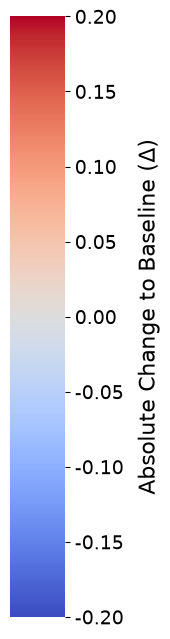

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create figure with dimensions tailored to orientation
if orientation == "vertical":
    fig, ax = plt.subplots(figsize=(1.8, 6.5))
elif orientation == "horizontal":
    fig, ax = plt.subplots(figsize=(6.5, 1.8))
else:
    raise ValueError(f"Invalid orientation '{orientation}'. Expected 'vertical' or 'horizontal'.")

# Set up color mapping matching heatmap configuration (coolwarm, vmin=-0.2, vmax=0.2)
vmin, vmax = -0.2, 0.2
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("coolwarm")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Ticks from -0.20 to 0.20 with 0.05 step size
ticks = np.linspace(vmin, vmax, 9)
tick_labels = [f"{0.00:.2f}" if abs(t) < 1e-9 else f"{t:.2f}" for t in ticks]

# Generate colorbar
if orientation == "vertical":
    cbar = fig.colorbar(sm, cax=ax, orientation="vertical", ticks=ticks)
    cbar.ax.set_yticklabels(tick_labels, fontsize=tick_text_font_size)
    cbar.set_label("Absolute Change to Baseline (Δ)", fontsize=legend_text_font_size, labelpad=10)
else:
    cbar = fig.colorbar(sm, cax=ax, orientation="horizontal", ticks=ticks)
    cbar.ax.set_xticklabels(tick_labels, fontsize=tick_text_font_size)
    cbar.set_label("Absolute Change to Baseline (Δ)", fontsize=legend_text_font_size, labelpad=10)

# Toggle colorbar outline frame
cbar.outline.set_visible(use_frame)

plt.tight_layout()

if save_legend:
    plt.savefig(output_filename, dpi=1000, bbox_inches="tight")
    print(f"[Success] Saved heatmap legend graphic to: {output_filename}")

plt.show()